# 1. Inputs, Targets and Tagger Outputs

To load the relevant packages, files and basic data structure, just execute the following cells. This will also give you a first glimpse into what the files contain as information.

In [1]:
import uproot

In [2]:
import awkward as ak

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
from glob import glob

In [6]:
filelist_TTToSemileptonic = glob("/work/projects/hats2024/tagging/TTtoLNu2Q_Run3Summer23NanoAODv12/*.root")

#If you are using lxplus, replace the path with `/eos/cms/store/group/phys_btag/HATS2024`

In [7]:
filelist_TTToSemileptonic # We'll use just the first file for this exercise. You can change the following code to use all three to improve stats.

['/work/projects/hats2024/tagging/TTtoLNu2Q_Run3Summer23NanoAODv12/48499a72-5cf2-43d6-ac91-be767c9a0251.root',
 '/work/projects/hats2024/tagging/TTtoLNu2Q_Run3Summer23NanoAODv12/04fb6a6e-b9c5-4df1-99fa-c804ef776cba.root',
 '/work/projects/hats2024/tagging/TTtoLNu2Q_Run3Summer23NanoAODv12/064f3cdb-1e93-4808-b36a-e96cdd41b641.root']

In [8]:
filelist_QCD_Pt_170_300 = glob("/work/projects/hats2024/tagging/QCD_PT-170to300_Run3Summer23NanoAODv12/*.root")
#If you are using lxplus, replace the path with `/eos/cms/store/group/phys_btag/HATS2024`

In [9]:
filelist_QCD_Pt_170_300

['/work/projects/hats2024/tagging/QCD_PT-170to300_Run3Summer23NanoAODv12/2a192aa2-ff46-4e0e-b0e3-f58ec3313911.root']

In [10]:
sample_file = uproot.open(filelist_TTToSemileptonic[0])
whats_inside = sample_file['Events'].keys() # 'Events' is the relevant entry-point into the many branches stored with event and object information

In [11]:
whats_inside

['run',
 'luminosityBlock',
 'event',
 'bunchCrossing',
 'HTXS_njets25',
 'HTXS_njets30',
 'HTXS_stage1_1_cat_pTjet25GeV',
 'HTXS_stage1_1_cat_pTjet30GeV',
 'HTXS_stage1_1_fine_cat_pTjet25GeV',
 'HTXS_stage1_1_fine_cat_pTjet30GeV',
 'HTXS_stage1_2_cat_pTjet25GeV',
 'HTXS_stage1_2_cat_pTjet30GeV',
 'HTXS_stage1_2_fine_cat_pTjet25GeV',
 'HTXS_stage1_2_fine_cat_pTjet30GeV',
 'HTXS_stage_0',
 'HTXS_stage_1_pTjet25',
 'HTXS_stage_1_pTjet30',
 'HTXS_Higgs_pt',
 'HTXS_Higgs_y',
 'BeamSpot_type',
 'BeamSpot_sigmaZ',
 'BeamSpot_sigmaZError',
 'BeamSpot_z',
 'BeamSpot_zError',
 'nboostedTau',
 'boostedTau_idAntiEle2018',
 'boostedTau_idAntiMu',
 'boostedTau_idMVAnewDM2017v2',
 'boostedTau_idMVAoldDM2017v2',
 'boostedTau_jetIdx',
 'boostedTau_rawAntiEleCat2018',
 'boostedTau_charge',
 'boostedTau_decayMode',
 'boostedTau_chargedIso',
 'boostedTau_eta',
 'boostedTau_leadTkDeltaEta',
 'boostedTau_leadTkDeltaPhi',
 'boostedTau_leadTkPtOverTauPt',
 'boostedTau_mass',
 'boostedTau_neutralIso',
 'boost

In [12]:
jet_keys = sample_file['Events'].keys(filter_name=['Jet_*']) # you can also use regular-expression like syntax to select only certain keys matching given pattern
jet_keys # in this exercise, we will work with so called AK4 jets (i.e. radius R = 0.4), in NanoAOD and PFNano abbreviated with "Jet"

['Jet_jetId',
 'Jet_nConstituents',
 'Jet_nElectrons',
 'Jet_nMuons',
 'Jet_nSVs',
 'Jet_electronIdx1',
 'Jet_electronIdx2',
 'Jet_muonIdx1',
 'Jet_muonIdx2',
 'Jet_svIdx1',
 'Jet_svIdx2',
 'Jet_hfadjacentEtaStripsSize',
 'Jet_hfcentralEtaStripSize',
 'Jet_PNetRegPtRawCorr',
 'Jet_PNetRegPtRawCorrNeutrino',
 'Jet_PNetRegPtRawRes',
 'Jet_area',
 'Jet_btagDeepFlavB',
 'Jet_btagDeepFlavCvB',
 'Jet_btagDeepFlavCvL',
 'Jet_btagDeepFlavQG',
 'Jet_btagPNetB',
 'Jet_btagPNetCvB',
 'Jet_btagPNetCvL',
 'Jet_btagPNetQvG',
 'Jet_btagPNetTauVJet',
 'Jet_btagRobustParTAK4B',
 'Jet_btagRobustParTAK4CvB',
 'Jet_btagRobustParTAK4CvL',
 'Jet_btagRobustParTAK4QG',
 'Jet_chEmEF',
 'Jet_chHEF',
 'Jet_eta',
 'Jet_hfsigmaEtaEta',
 'Jet_hfsigmaPhiPhi',
 'Jet_mass',
 'Jet_muEF',
 'Jet_muonSubtrFactor',
 'Jet_neEmEF',
 'Jet_neHEF',
 'Jet_phi',
 'Jet_pt',
 'Jet_rawFactor',
 'Jet_hadronFlavour',
 'Jet_genJetIdx',
 'Jet_partonFlavour']

In [13]:
#Go through all the jet properties. Which are the discriminators?

jets = sample_file['Events'].arrays(jet_keys) # there are multiple ways to actually get the arrays corresponding to the keys, one is here
jets

<Array [{Jet_jetId: [6, 2, 6, 6, ... 2, 0, 0]}] type='84000 * {"Jet_jetId": var ...'>

In [14]:
# another way to get the info, useful if you want to specify the library for further processing (if different from ak)
# or if you want to use chunks (here: all entries as an example, could be another integer)
for sample_jets in sample_file['Events'].iterate(jet_keys, step_size=sample_file['Events'].num_entries, library='ak'):
    break

In [15]:
sample_jets

<Array [{Jet_jetId: [6, 2, 6, 6, ... 2, 0, 0]}] type='84000 * {"Jet_jetId": var ...'>

In [16]:
# Typically, we need only "good-quality" jets. All b-tagging corrections are derived on these jets only.

# sample_jets = sample_jets[(abs(sample_jets["Jet_eta"])<2.5) & (sample_jets["Jet_pt"]>20) & (sample_jets['Jet_jetId']>4)]

# What is the above code doing? Try the rest of the exercise with this line commented out and then uncommented!

## Input and target study

1. Plot the following quantities in histograms, inclusively for all jets:
   - Jet_eta
   - Jet_pt
   - All discriminators 
   _Hint:_ It may be useful to write a function for convenience and just call the function multiple times.

2. Obtain the truth flavour of the jets by utilizing some of the following branches as introduced in the introductory presentation:
   - Jet_hadronFlavour
   - Jet_partonFlavour
     
    a) Show the truth flavour distribution for all jets: b, c, udsg via a histogram.
    b) Store the flavour array for later usage. _It will be used for slicing in the next question:_

3. Plot the same quantities as in 1., but now split them by flavour (into the four categories from above). Describe the distributions.

(0.0, 9175.32)

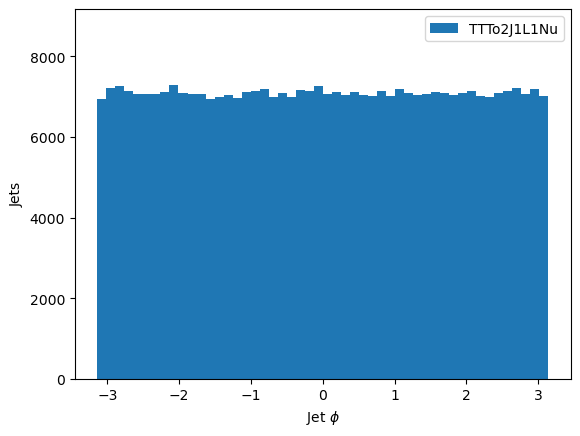

In [44]:
# Example for 1.:
jet_phi = ak.flatten(sample_jets['Jet_phi'], axis=-1)

plt.hist(jet_phi, bins=50, label='TTTo2J1L1Nu')
plt.xlabel(r'Jet $\phi$')
plt.ylabel(r'Jets')
plt.legend()
axes = plt.gca()
y_lower, y_upper = axes.get_ylim()
plt.ylim([y_lower, y_upper * 1.2])

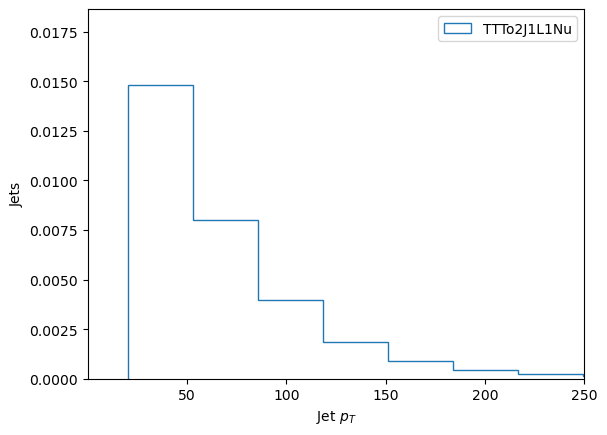

In [54]:
# Your code for 1. here

def jet_plotter(jet_var_array, sample_label, x_label, xlow=None, xhigh=None):
    jet_var = ak.flatten(jet_var_array, axis=-1) 
    plt.hist(jet_var, bins=50, label=sample_label, histtype='step',density='True')
    plt.xlabel(x_label)
    plt.ylabel(r'Jets')
    plt.legend()
    axes = plt.gca()
    y_lower, y_upper = axes.get_ylim()
    plt.ylim([y_lower, y_upper * 1.2])
    if xlow:
        plt.xlim(xlow,xhigh)
    


jet_plotter(sample_jets['Jet_pt'],'TTTo2J1L1Nu','Jet $p_{T}$',0.01,250)




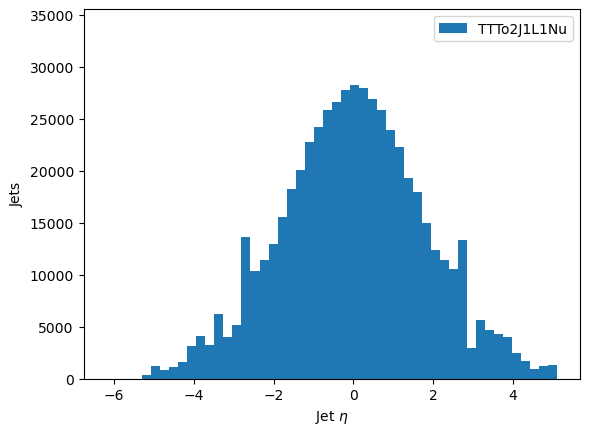

In [19]:
jet_plotter(sample_jets['Jet_eta'],'TTTo2J1L1Nu','Jet $\eta$')

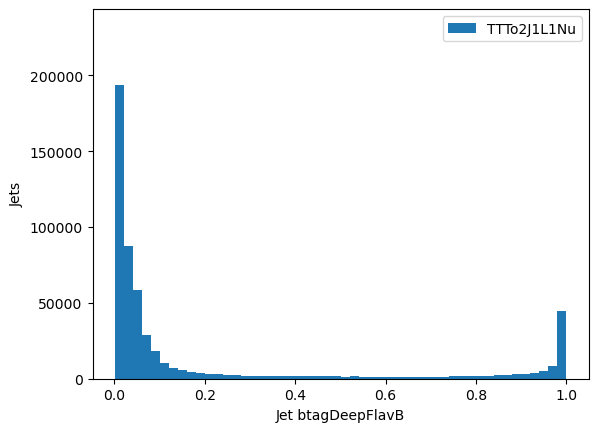

In [20]:
jet_plotter(sample_jets['Jet_btagDeepFlavB'],'TTTo2J1L1Nu','Jet btagDeepFlavB')

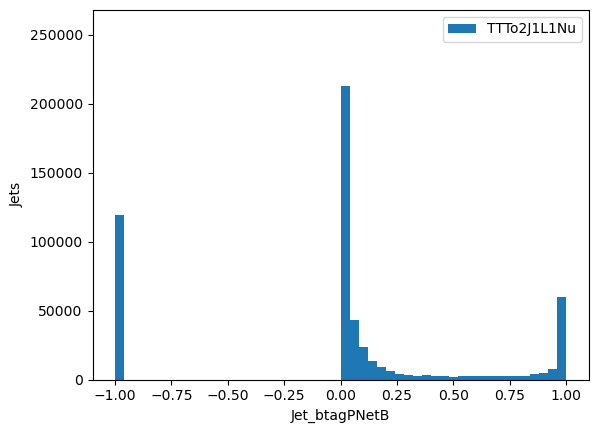

In [21]:
jet_plotter(sample_jets['Jet_btagPNetB'],'TTTo2J1L1Nu', 'Jet_btagPNetB')

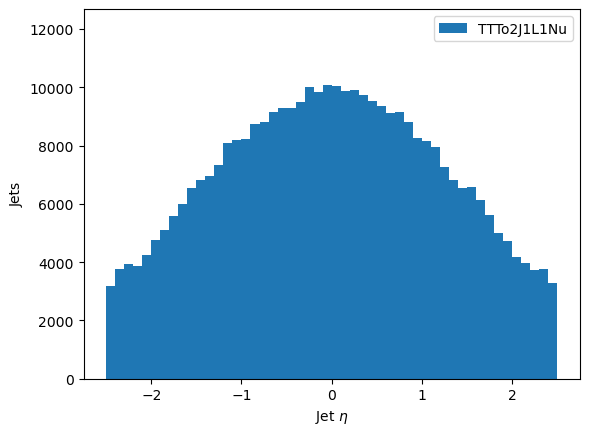

In [22]:
sample_jets = sample_jets[(abs(sample_jets["Jet_eta"])<2.5) & (sample_jets["Jet_pt"]>20) & (sample_jets['Jet_jetId']>4)] 
jet_plotter(sample_jets['Jet_eta'],'TTTo2J1L1Nu','Jet $\eta$')

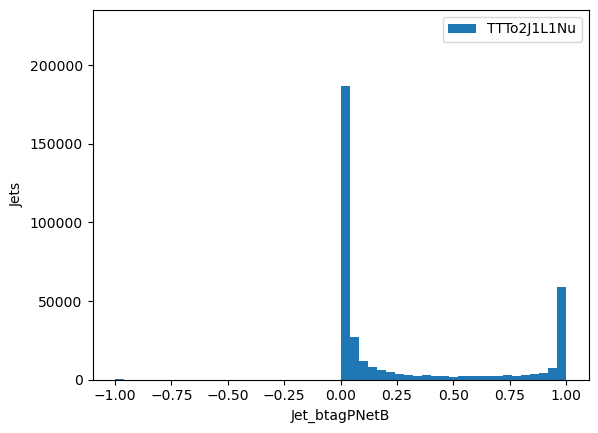

In [23]:
jet_plotter(sample_jets['Jet_btagPNetB'],'TTTo2J1L1Nu', 'Jet_btagPNetB')

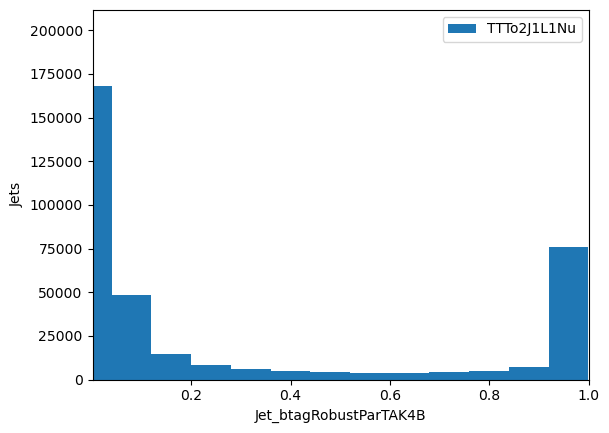

In [28]:
jet_plotter(sample_jets['Jet_btagRobustParTAK4B'],'TTTo2J1L1Nu', 'Jet_btagRobustParTAK4B',0.001,1)

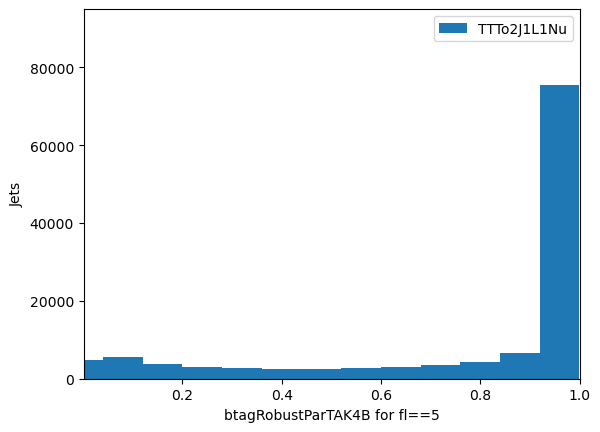

In [29]:
# Now your turn to plot the distribution from the sample and answer question 2 here

b_jets = sample_jets[sample_jets["Jet_hadronFlavour"]==5]
c_jets = sample_jets[sample_jets["Jet_hadronFlavour"]==4]
l_jets = sample_jets[sample_jets["Jet_hadronFlavour"]<4]

jet_plotter(b_jets['Jet_btagRobustParTAK4B'],'TTTo2J1L1Nu', 'btagRobustParTAK4B for fl==5',0.001,1)

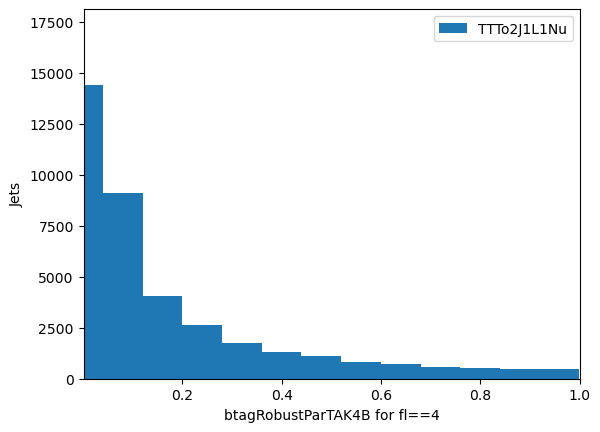

In [32]:
jet_plotter(c_jets['Jet_btagRobustParTAK4B'],'TTTo2J1L1Nu', 'btagRobustParTAK4B for fl==4',0.001,1)

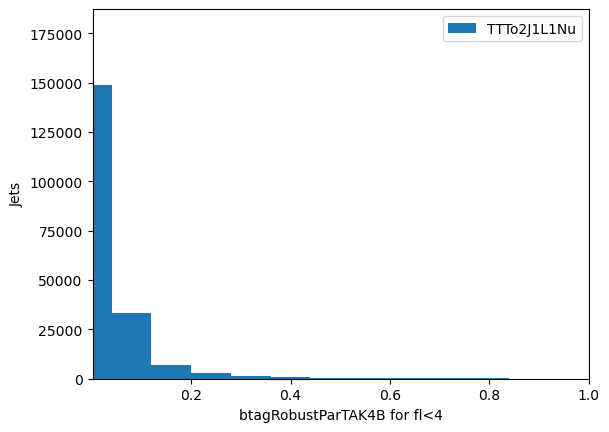

In [33]:
jet_plotter(l_jets['Jet_btagRobustParTAK4B'],'TTTo2J1L1Nu', 'btagRobustParTAK4B for fl<4',0.001,1)

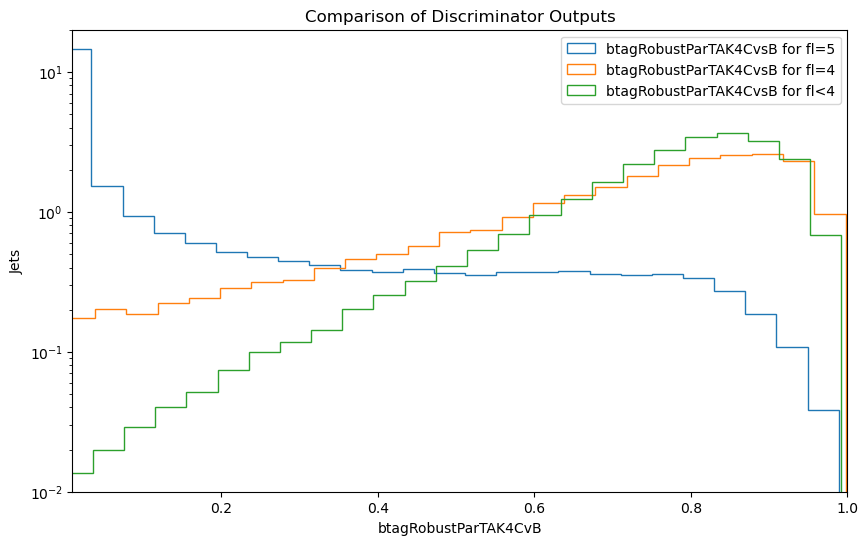

In [58]:
plt.figure(figsize=(10, 6))
jet_plotter(b_jets['Jet_btagRobustParTAK4CvB'],'btagRobustParTAK4CvsB for fl=5' , 'btagRobustParTAK4CvB',0.01,1)
jet_plotter(c_jets['Jet_btagRobustParTAK4CvB'], 'btagRobustParTAK4CvsB for fl=4', 'btagRobustParTAK4CvB',0.01,1)
jet_plotter(l_jets['Jet_btagRobustParTAK4CvB'], 'btagRobustParTAK4CvsB for fl<4', 'btagRobustParTAK4CvB',0.01,1)

# Show the plot
plt.title("Comparison of Discriminator Outputs")
plt.ylim(0.01,20)
plt.yscale('log')
plt.show()

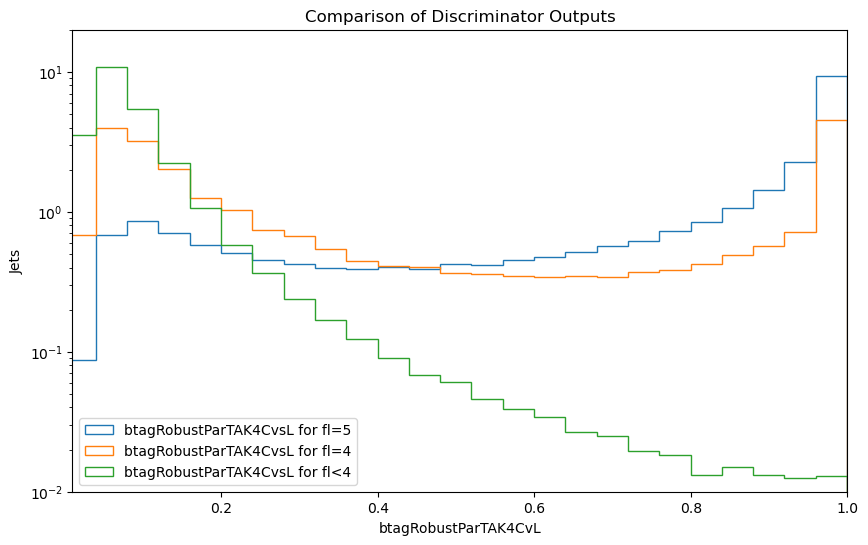

In [59]:
plt.figure(figsize=(10, 6))
jet_plotter(b_jets['Jet_btagRobustParTAK4CvL'],'btagRobustParTAK4CvsL for fl=5' , 'btagRobustParTAK4CvL',0.01,1)
jet_plotter(c_jets['Jet_btagRobustParTAK4CvL'], 'btagRobustParTAK4CvsL for fl=4', 'btagRobustParTAK4CvL',0.01,1)
jet_plotter(l_jets['Jet_btagRobustParTAK4CvL'], 'btagRobustParTAK4CvsL for fl<4', 'btagRobustParTAK4CvL',0.01,1)

# Show the plot
plt.title("Comparison of Discriminator Outputs")
plt.ylim(0.01,20)
plt.yscale('log')
plt.show()

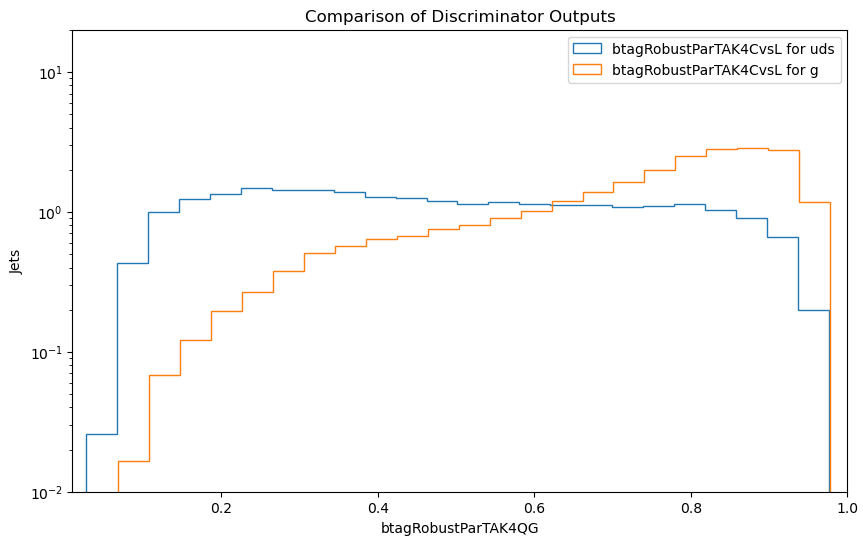

In [64]:
uds_jets = sample_jets[(sample_jets["Jet_hadronFlavour"]<4) & (sample_jets["Jet_partonFlavour"]>=1) & (sample_jets["Jet_partonFlavour"]<=3)]
g_jets = sample_jets[(sample_jets["Jet_hadronFlavour"]<4) & (sample_jets["Jet_partonFlavour"]==21)]


plt.figure(figsize=(10, 6))
jet_plotter(uds_jets['Jet_btagRobustParTAK4QG'],'btagRobustParTAK4CvsL for uds' , 'btagRobustParTAK4QG',0.01,1)
jet_plotter(g_jets['Jet_btagRobustParTAK4QG'], 'btagRobustParTAK4CvsL for g', 'btagRobustParTAK4QG',0.01,1)

# Show the plot
plt.title("Comparison of Discriminator Outputs")
plt.ylim(0.01,20)
plt.yscale('log')
plt.show()


## Tagger outputs

In the present files, you have access to several pre-computed tagger output distributions, coming from various generations of algorithms. The b-tagging / flavour-tagging scores or discriminators start with `Jet_btag`, then further specify the specific network and, if multi-classification, also which output score or which discriminator is stored. DeepFlav is another way to name DeepJet. PNet and RobustParTAK4 are two new classifiers introduced in Run-3.

1. Plot all available tagger output scores (if available, individual probabilities) and discriminators, split by flavour.
2. For B, CvB, CvL discriminators, compare DeepJet, PNet and ParT qualitatively. Describe the structure close to 0, 1 and if there are particularly outstanding, unexpected values.
3. _(Bonus)_ If you finish the above before our first group discussion, run the cells also for one example file of the other set of samples (QCD_Pt_170_300) and compare with the results for semileptonic $t\bar{t}$ events. Are there noticeable differences?

In [40]:
# Hint for 1.: you have already learned how to split by flavour in a previous question,
#     and to get all the branches that we ask for, utilize the regular-expression-trick introduced at the beginning
#     (as you may want to automize this instead of searching and copy-pasting...)
# Hint for 2.: remember how discriminators of type XvsY are defined to answer the second part
# Hint for 3.: Start from the inputs with the comparison, this will give you the full picture.

In [41]:
# Your code for tagger outputs here

## AK8 jet tagging

Now let's have a look at the AK8 jets. In NanoAOD they are stored as "FatJet_*".

In [42]:
fatjet_keys = sample_file['Events'].keys(filter_name=['FatJet_*'])
fatjet_keys

['FatJet_jetId',
 'FatJet_nConstituents',
 'FatJet_subJetIdx1',
 'FatJet_subJetIdx2',
 'FatJet_electronIdx3SJ',
 'FatJet_muonIdx3SJ',
 'FatJet_area',
 'FatJet_btagDDBvLV2',
 'FatJet_btagDDCvBV2',
 'FatJet_btagDDCvLV2',
 'FatJet_btagDeepB',
 'FatJet_btagHbb',
 'FatJet_eta',
 'FatJet_mass',
 'FatJet_msoftdrop',
 'FatJet_n2b1',
 'FatJet_n3b1',
 'FatJet_particleNetWithMass_H4qvsQCD',
 'FatJet_particleNetWithMass_HbbvsQCD',
 'FatJet_particleNetWithMass_HccvsQCD',
 'FatJet_particleNetWithMass_QCD',
 'FatJet_particleNetWithMass_TvsQCD',
 'FatJet_particleNetWithMass_WvsQCD',
 'FatJet_particleNetWithMass_ZvsQCD',
 'FatJet_particleNet_QCD',
 'FatJet_particleNet_QCD0HF',
 'FatJet_particleNet_QCD1HF',
 'FatJet_particleNet_QCD2HF',
 'FatJet_particleNet_XbbVsQCD',
 'FatJet_particleNet_XccVsQCD',
 'FatJet_particleNet_XggVsQCD',
 'FatJet_particleNet_XqqVsQCD',
 'FatJet_particleNet_XteVsQCD',
 'FatJet_particleNet_XtmVsQCD',
 'FatJet_particleNet_XttVsQCD',
 'FatJet_particleNet_massCorr',
 'FatJet_phi',


Now load these fatjets.

In [43]:
fatjets = sample_file['Events'].arrays(fatjet_keys)

We can now look at the distributions of the discriminators of AK8 jets. Plot the quantities `FatJet_particleNetWithMass_TvsQCD` and `FatJet_particleNetWithMass_TvsQCD`. These are the probabilities of the jet being a hadronic top and a hadronic W jet, respectively. 

In [44]:
# Your code here to make the plots. Use the same techniques as before, i.e. get the array, flatten it along axis -1, and plot using plot.hist. Use `range=(0,1)` in the plot command.

Discuss what you observe. Can we enrich the events with high-$p_T$ top quarks? Remember that the entire top decay is contained within a single AK8 jet only at high boosts of the top quark. Following is a trick to select only those events with a high-$p_T$ generated top quark in it. This will only work with simulated samples.

In [45]:
# The GenPart branch in NanoAOD contains information about the generator level "truth" particles. We can access it as follows.
genpart_keys = sample_file['Events'].keys(filter_name=['GenPart_*'])
genpart_keys 

['GenPart_genPartIdxMother',
 'GenPart_statusFlags',
 'GenPart_pdgId',
 'GenPart_status',
 'GenPart_eta',
 'GenPart_mass',
 'GenPart_phi',
 'GenPart_pt']

In [46]:
genpart = sample_file['Events'].arrays(genpart_keys)

Now let's select only those events which have a high-$p_T$ top quark. We can define an "event mask" which is a list of booleans telling us whether an event is selected (True) or not (False).

In [47]:
event_mask = ak.any((abs(genpart['GenPart_pdgId'])==6) & (genpart['GenPart_pt']>500),axis=-1)
# abs(pdgid)==6 corresponds to the top quark's PDGID.
# ak.any() is true whenever any genparticle in the event satisfies both the conditions. So any event containing a top quark above 500 GeV gets set to True.
event_mask

<Array [False, False, False, ... False, False] type='84000 * bool'>

Do you see a lot of Falses? Discuss why. Play around with the $p_T$ threshold of 500. Set it to 0, 50, 100, and so on. Do you select more events this way?

In [48]:
# Now apply this event_mask on the fatjets. This will give you fatjets from only those events which contain at least 1 high-$p_T$ top quark at the truth level.
selected_fatjets = fatjets[event_mask]

Now plot `selected_fatjets['FatJet_particleNetWithMass_TvsQCD']`.
What changed? Do this with several $p_T$ thresholds on the generated top quark.

In [49]:
#Your plotting code here

### AK8 Bonus

_This requires advanced knowledge of coffea and will not be covered in the tutorial. But this gives the concept of truth definitions for heavy-object tagging._

You had "hadronFlavour" for AK4 jets to define the "truth" for each jet. In case of AK8 jets it is more complicated because they are typically not the result of simply one single hadron, but have a multi-pronged structure. We can define true hadronic W and true hadronic top in the following way:
- Look for a W boson (pdgid $\pm$24) in the GenPart collection. Check if it decays into partons (daughter of the W are u/d/s/c, i.e., pdgids $\pm$1/2/3/4). Check if both the partons lie within a radius of 0.8 from the center of the AK8 jet (use deltaR(jet,parton)<0.8). If both partons lie within 0.8 of the same AK8 jet, the jet may be labelled as a true W or a true top (check next point).
- Once you have identified hadronic W's, check if its mother is a top quark (tip: you may have to recursively look for mothers since each particle typically has multiple copies. The W that decays to partons may have a W as a mother, which will have W as a mother and so on. You need to check for the first W in the decay chain, and its mother should be a top), and find the b quark (pdgid $\pm$5) that is also a daughter of this top quark. If this b quark also lies within a radius of 0.8 around the AK8 jet, the jet will be labelled top. Otherwise it will be labelled W.

Once you have labelled your top quarks and W bosons, plot the distributions of their `FatJet_particleNetWithMass_TvsQCD` and `FatJet_particleNetWithMass_TvsQCD` values.

